In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Dermal toxicity\dataset\train_set_acute_Dermal_features.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())


Train DataFrame:
  Outcome                                 Morgan_Descriptors  \
0     0.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
1     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
4     0.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [0.8740247872038239, 0.39064055488963423, 0.40...  335   
1  [-0.940474802814492, -0.4830269230698603, -0.4...    6   
2  [-1.2176168183559164, -0.5653367076993571, -0....  104   
3  [-0.1845970849

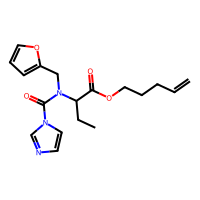

C=CCCCOC(=O)C(CC)N(Cc1ccco1)C(=O)n1ccnc1


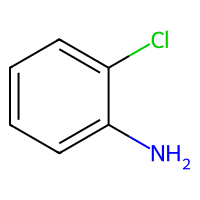

Nc1ccccc1Cl


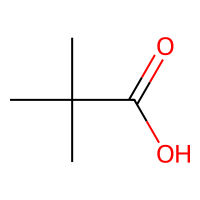

CC(C)(C)C(=O)O


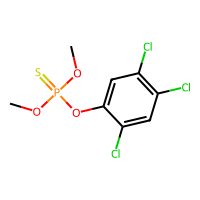

COP(=S)(OC)Oc1cc(Cl)c(Cl)cc1Cl


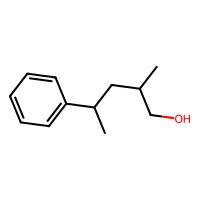

CC(CO)CC(C)c1ccccc1


In [3]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(moldf, num_mols):
    for _, row in moldf.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Display the first 10 molecules, each on a new row
display_molecules_in_column(train_df, 5)


In [4]:
train_df

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8740247872038239, 0.39064055488963423, 0.40...",335,C=CCCCOC(=O)C(CC)N(Cc1ccco1)C(=O)n1ccnc1,345.16885621600005,3.2344000000000017,146.44278980417016,77.57000000000001,...,0.0,5.0,11.0,0.5,12.0,0.0,77.57000000000001,5.700439718141093,1.6619999999999997,0.3888888888888889
1,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.940474802814492, -0.4830269230698603, -0.4...",6,Nc1ccccc1Cl,127.01887687199999,1.9222,53.07456004339135,26.02,...,1.0,0.0,0.0,0.25,0.0,0.0,26.02,4.0,1.827,0.0
2,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.2176168183559164, -0.5653367076993571, -0....",104,CC(C)(C)C(=O)O,102.06807956,1.1171,43.15477533765576,37.3,...,1.0,3.0,4.0,0.3333333333333333,1.0,0.0,37.3,3.584962500721156,0.6670000000000001,0.8
3,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.1845970849964794, 0.3208418027043526, 0.41...",114,COP(=S)(OC)Oc1cc(Cl)c(Cl)cc1Cl,319.899734786,4.542900000000002,113.7916498206688,27.69,...,0.0,0.0,5.0,0.5,4.0,1.0,69.59,5.0,5.044,0.25
4,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4196464997252898, -0.263724400254024, -0.2...",489,CC(CO)CC(C)c1ccccc1,178.135765196,2.808600000000001,80.41528955807264,20.23,...,1.0,5.0,6.0,0.5,4.0,0.0,20.23,4.700439718141093,3.097000000000001,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.43794972643216606, -0.17278339070284307, -...",71,COC(=O)C=C(C)OP(=O)(OC)OC,224.044974766,1.4807,82.40461437457131,71.06,...,0.0,4.0,9.0,0.5,6.0,0.0,80.87,4.700439718141093,0.0429999999999999,0.5714285714285714
499,1.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3791770258836246, 0.21303177327787326, 0.2...",106,O=CNC(N1CCOCC1)C(Cl)(Cl)Cl,259.988610632,0.7609000000000004,97.41763442468701,41.57000000000001,...,1.0,2.0,6.0,0.4285714285714285,4.0,0.0,41.57000000000001,4.807354922057604,0.937,0.8571428571428571
500,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5636934239974333, -0.30288732329230444, -0...",271,CNC(=O)Oc1cccc(C)c1,165.078978592,1.71322,71.35115897584546,38.33,...,1.0,0.0,4.0,0.4285714285714285,3.0,0.0,38.33,4.584962500721156,1.8840000000000003,0.2222222222222222
501,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.261452310398232, 1.165313603467914, 1.31145...",438,CN(C)c1ccc(C(O)(c2ccc(N(C)C)cc2)c2ccc(Nc3ccccc...,487.262362676,6.999600000000006,218.972824117618,38.74,...,2.0,0.0,3.0,0.4666666666666667,7.0,1.0,38.74,6.357552004618084,7.648999999999999,0.1515151515151515


In [5]:
train_df= train_df.sort_values(['Outcome'], ascending=True)
train_df['RowID'] = train_df.index
train_df.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,RowID
0,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8740247872038239, 0.39064055488963423, 0.40...",335,C=CCCCOC(=O)C(CC)N(Cc1ccco1)C(=O)n1ccnc1,345.16885621600005,3.2344000000000017,146.44278980417016,77.57000000000001,...,5.0,11.0,0.5,12.0,0.0,77.57000000000001,5.700439718141093,1.6619999999999997,0.3888888888888889,0
391,0.0,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2298496296306658, 0.0685477391827318, 0.14...",399,CSc1nc(NC(C)C)nc(NC(C)C)n1,241.13611660799998,2.2340999999999998,100.86777625569405,62.730000000000004,...,3.0,3.0,0.375,5.0,0.0,88.03,5.0,2.244,0.7,391
217,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.26128770023118847, 0.4364773421802139, 0.5...",372,O=C(O)c1cc(C(=O)O)cc(S(=O)(=O)O)c1,245.98342353200002,0.3297,89.70143506281035,128.96999999999997,...,0.0,3.0,0.3333333333333333,3.0,0.0,137.34999999999997,5.0,-0.1540000000000002,0.0,217
216,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.4574884506660009, 0.3838732232831581, 0.480...",382,COC=C(C(=O)OC)c1ccccc1Oc1cc(Oc2ccccc2C#N)ncn1,403.11682064400014,4.093180000000004,172.49321984725344,103.56,...,3.0,7.0,0.5,8.0,0.0,103.56,6.0,4.223,0.0909090909090909,216
392,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.46197289976775313, 0.0312372497352413, 0.10...",527,CCCCCCCCOC(=O)C(C)Oc1ccc(Cl)cc1C,326.16487240400005,5.319420000000005,138.50258727819548,35.53,...,8.0,12.0,0.5,11.0,2.0,35.53,5.459431618637297,6.640000000000001,0.6111111111111112,392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,0.0,"[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8488264075438349, 0.5594769702609498, 0.639...",413,N#CC(CCc1ccc(Cl)cc1)(Cn1cncn1)c1ccccc1,336.114174224,4.025880000000003,145.8930294498658,54.5,...,4.0,5.0,0.4545454545454545,6.0,0.0,54.5,5.700439718141093,4.227000000000001,0.2105263157894736,333
331,0.0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[4.286725365434071, 1.0883371359812126, 1.2295...",318,O=S(=O)(O)OCCS(=O)(=O)c1ccc(N=Nc2c(S(=O)(=O)O)...,1002.929625292,2.966,355.45750387549845,411.8999999999999,...,2.0,7.0,0.5,18.0,4.0,462.1799999999999,7.044394119358453,-1.9450000000000007,0.1379310344827586,331
344,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0260081952737905, 0.4662682966015862, 0.567...",378,CCN(CC)c1ccc(N=Nc2c(C#N)cc([N+](=O)[O-])cc2C#N...,362.149123816,4.908180000000004,156.68783872646694,118.68,...,2.0,5.0,0.5,6.0,0.0,118.68,5.807354922057604,4.759000000000002,0.2631578947368421,344
350,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8914972699077947, -0.17389828355801953, -0....",349,CCOC(=O)CCN(Cc1ccccc1)SN(C)C(=O)ON=C(C)SC,399.12864828,3.7698000000000027,162.8819044346933,71.44,...,3.0,15.0,0.5,13.0,1.0,122.04,5.700439718141093,3.5669999999999997,0.4705882352941176,350


Classes                          :  ['0.0' '1.0']
Number of cpds in each class     :  [246 257]
Total number of cpds             :  503


{'0.0': 0, '1.0': 1}

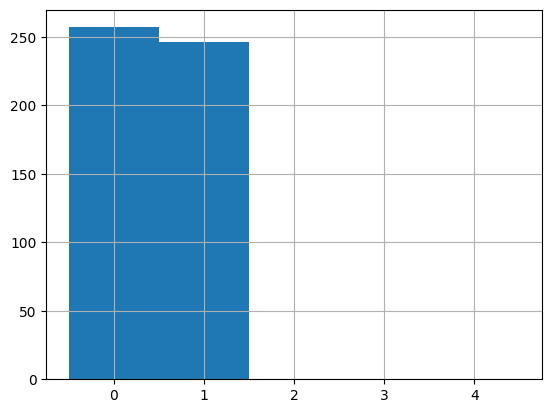

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(train_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( train_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =train_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#GRAPH 
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [7]:
y= np.int32((S))
x = np.array(list(train_df['Morgan_Descriptors']))

In [8]:
print(x)

[[0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [10]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

paramgrid = {
    "max_features": [
         x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 8
    ],
     "n_estimators": [50, 200],

}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Everything else remains the same in your GridSearchCV initialization and fitting
model_rf_morgan = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=1) 

# Fit the model
model_rf_morgan.fit(x, y)
best_model_rf_morgan = model_rf_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [11]:
#SVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
     "C": [0.1, 1], #Regularization
     "kernel": ['linear','rbf'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient

}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with SVC
model_svm_morgan = GridSearchCV(
    estimator=SVC(probability=True), 
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1 
)

# Fit the model
model_svm_morgan.fit(x, y)
best_model_svm_morgan = model_svm_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [12]:
#MXGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
     "max_depth": [3,7],
     "n_estimators": [100,300],
     "learning_rate": [0.05,0.2],  # Step size shrinkage used to prevent overfitting
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with XGBClassifier
model_xgb_morgan = GridSearchCV(
    estimator=XGBClassifier(eval_metric='mlogloss'),  
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit the model
model_xgb_morgan.fit(x, y)
best_model_xgb_morgan = model_xgb_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [9]:
#Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid_nn = {
    "hidden_layer_sizes": [(100,), (100, 50)],  # Arsitektur 
    "activation": ['relu', 'tanh'],             # fungsi aktivasi 
    "solver": ['adam', 'lbfgs'],              
    "alpha": [0.0001]                          
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_morgan = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit the model
model_nn_morgan.fit(x, y)
best_model_nn_morgan = model_nn_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [14]:
#GPC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
import numpy as np

# Parameter grid (8 kombinasi total)
paramgrid_gpc = {
    'kernel': [
        1.0 * RBF(length_scale=1.0),
        1.0 * RBF(length_scale=2.0),
        1.0 * Matern(length_scale=1.0, nu=1.5),
        1.0 * Matern(length_scale=2.0, nu=2.5),
        1.0 * RationalQuadratic(length_scale=1.0, alpha=1.0),
        1.0 * RationalQuadratic(length_scale=2.0, alpha=0.5),
        1.0 * RBF(length_scale=1.0) + 1.0 * Matern(length_scale=1.0, nu=1.5),
        1.0 * RBF(length_scale=2.0) + 1.0 * RationalQuadratic(length_scale=1.0, alpha=0.5)
    ]
}

# Cross-validation setup
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Scoring menggunakan Cohen’s Kappa berbobot quadratic
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# GridSearchCV setup
model_gpc_morgan = GridSearchCV(
    estimator=GaussianProcessClassifier(random_state=42, max_iter_predict=100),
    param_grid=paramgrid_gpc,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit model
model_gpc_morgan.fit(x, y)
best_model_gpc_morgan = model_gpc_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [15]:
#LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid (Tetap sama)
paramgrid = {
     "max_depth": [3,7],
     "n_estimators": [100,300],
     "learning_rate": [0.05,0.2]
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with LGBMClassifier
model_lgbm_morgan = GridSearchCV(
    estimator=LGBMClassifier(verbosity=-1, force_row_wise=True),  
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1, 
    n_jobs=1 
)

# Fit the model
model_lgbm_morgan.fit(x, y)
best_model_lgbm_morgan = model_lgbm_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [16]:
#CatBoost 

from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
     "depth": [3,7],            # Identik dengan max_depth
     "iterations": [100,300],   # Identik dengan n_estimators
     "learning_rate": [0.05,0.2]
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with CatBoostClassifier
model_cbm_morgan = GridSearchCV(
    estimator=CatBoostClassifier(verbose=0), # verbose=0 agar tidak penuh log setiap iterasi
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1 
)

# Fit the model
model_cbm_morgan.fit(x, y)
best_model_cbm_morgan = model_cbm_morgan.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [17]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_morgan.predict(X_test)
    y_proba = best_model_rf_morgan.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  # Binary class AUC
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[42 10]
 [18 31]]
Confusion Matrix for Fold 2:
[[41 11]
 [14 35]]
Confusion Matrix for Fold 3:
[[40 11]
 [18 32]]
Confusion Matrix for Fold 4:
[[37 14]
 [15 34]]
Confusion Matrix for Fold 5:
[[38 13]
 [15 34]]
Overall CV Accuracy: 0.7236237623762376
Overall CV AUC: 0.7833699941515068
Overall CV Precision: 0.7385781522714223
Overall CV Recall (Sensitivity): 0.6749387755102041
Overall CV F1 Score: 0.7046534596662369
Overall CV Specificity: 0.770211161387632
Overall CV PPV (Positive Predictive Value): 0.7385781522714223
Overall CV NPV (Negative Predictive Value): 0.7127258622964543
Overall CV CCR (Correct Classification Rate): 0.7225749684489179


In [18]:
#untuk model SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_morgan.predict(X_test)
    y_proba = best_model_svm_morgan.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[47  5]
 [18 31]]
Confusion Matrix for Fold 2:
[[40 12]
 [12 37]]
Confusion Matrix for Fold 3:
[[39 12]
 [17 33]]
Confusion Matrix for Fold 4:
[[38 13]
 [17 32]]
Confusion Matrix for Fold 5:
[[40 11]
 [18 31]]
Overall CV Accuracy: 0.7315049504950496
Overall CV AUC: 0.7875374149659864
Overall CV Precision: 0.759750566893424
Overall CV Recall (Sensitivity): 0.6666938775510204
Overall CV F1 Score: 0.708284078555188
Overall CV Specificity: 0.7934389140271494
Overall CV PPV (Positive Predictive Value): 0.759750566893424
Overall CV NPV (Negative Predictive Value): 0.7138601054118295
Overall CV CCR (Correct Classification Rate): 0.7300663957890848


In [19]:
#XGBOOST
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_morgan.predict(X_test)
    y_proba = best_model_xgb_morgan.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[41 11]
 [15 34]]
Confusion Matrix for Fold 2:
[[37 15]
 [11 38]]
Confusion Matrix for Fold 3:
[[40 11]
 [17 33]]
Confusion Matrix for Fold 4:
[[38 13]
 [14 35]]
Confusion Matrix for Fold 5:
[[38 13]
 [14 35]]
Overall CV Accuracy: 0.7335841584158416
Overall CV AUC: 0.7752706005479115
Overall CV Precision: 0.736174004192872
Overall CV Recall (Sensitivity): 0.711591836734694
Overall CV F1 Score: 0.7227857846362937
Overall CV Specificity: 0.7549019607843137
Overall CV PPV (Positive Predictive Value): 0.736174004192872
Overall CV NPV (Negative Predictive Value): 0.7332538075959129
Overall CV CCR (Correct Classification Rate): 0.7332468987595038


In [20]:
#Neural Network NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model
    best_model_nn_morgan.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_nn_morgan.predict(X_test)
    y_proba = best_model_nn_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[37 15]
 [12 37]]
Confusion Matrix for Fold 2:
[[40 12]
 [16 33]]
Confusion Matrix for Fold 3:
[[39 12]
 [17 33]]
Confusion Matrix for Fold 4:
[[35 16]
 [16 33]]
Confusion Matrix for Fold 5:
[[32 19]
 [21 28]]
Overall CV Accuracy: 0.6896633663366337
Overall CV AUC: 0.7482085757379875
Overall CV Precision: 0.6894838393622588
Overall CV Recall (Sensitivity): 0.6666938775510204
Overall CV F1 Score: 0.6772680980189799
Overall CV Specificity: 0.7118401206636501
Overall CV PPV (Positive Predictive Value): 0.6894838393622588
Overall CV NPV (Negative Predictive Value): 0.6911728842480388
Overall CV CCR (Correct Classification Rate): 0.6892669991073352


In [21]:
# Evaluasi Gaussian Process Classifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model terbaik GPC
    best_model_gpc_morgan.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_gpc_morgan.predict(X_test)
    y_proba = best_model_gpc_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[40 12]
 [18 31]]
Confusion Matrix for Fold 2:
[[41 11]
 [12 37]]
Confusion Matrix for Fold 3:
[[38 13]
 [17 33]]
Confusion Matrix for Fold 4:
[[37 14]
 [15 34]]
Confusion Matrix for Fold 5:
[[39 12]
 [18 31]]
Overall CV Accuracy: 0.7176435643564357
Overall CV AUC: 0.7820214855172839
Overall CV Precision: 0.7276836872261544
Overall CV Recall (Sensitivity): 0.6748571428571428
Overall CV F1 Score: 0.6998487225459435
Overall CV Specificity: 0.7585972850678733
Overall CV PPV (Positive Predictive Value): 0.7276836872261544
Overall CV NPV (Negative Predictive Value): 0.7099796313675025
Overall CV CCR (Correct Classification Rate): 0.716727213962508


In [22]:
# Evaluasi LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_morgan.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_morgan.predict(X_test)
    y_proba = best_model_lgbm_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[41 11]
 [20 29]]
Confusion Matrix for Fold 2:
[[39 13]
 [17 32]]
Confusion Matrix for Fold 3:
[[31 20]
 [18 32]]
Confusion Matrix for Fold 4:
[[38 13]
 [19 30]]
Confusion Matrix for Fold 5:
[[40 11]
 [15 34]]
Overall CV Accuracy: 0.6879603960396039
Overall CV AUC: 0.7479326192015266
Overall CV Precision: 0.7009451401311867
Overall CV Recall (Sensitivity): 0.6382040816326531
Overall CV F1 Score: 0.6671131211685997
Overall CV Specificity: 0.7351432880844645
Overall CV PPV (Positive Predictive Value): 0.7009451401311867
Overall CV NPV (Negative Predictive Value): 0.6790304348266878
Overall CV CCR (Correct Classification Rate): 0.6866736848585588


In [23]:
# Evaluasi CatBOOst
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_cbm_morgan.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_cbm_morgan.predict(X_test)
    y_proba = best_model_cbm_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[38 14]
 [17 32]]
Confusion Matrix for Fold 2:
[[36 16]
 [15 34]]
Confusion Matrix for Fold 3:
[[32 19]
 [17 33]]
Confusion Matrix for Fold 4:
[[37 14]
 [16 33]]
Confusion Matrix for Fold 5:
[[33 18]
 [15 34]]
Overall CV Accuracy: 0.679940594059406
Overall CV AUC: 0.7538374734509189
Overall CV Precision: 0.67324827438981
Overall CV Recall (Sensitivity): 0.6748571428571428
Overall CV F1 Score: 0.6736758095314175
Overall CV Specificity: 0.6846153846153846
Overall CV PPV (Positive Predictive Value): 0.67324827438981
Overall CV NPV (Negative Predictive Value): 0.6870931751774466
Overall CV CCR (Correct Classification Rate): 0.6797362637362637


In [31]:
import joblib
joblib.dump(
    best_model_rf_morgan,
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_RF_morgan.pkl',
    compress=9)


['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_RF_morgan.pkl']

In [32]:
import joblib
joblib.dump(best_model_svm_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_SVM_morgan.pkl',
    compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_SVM_morgan.pkl']

In [10]:
import joblib
joblib.dump(best_model_nn_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_NN_morgan.pkl',
    compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_NN_morgan.pkl']

In [34]:
import joblib
joblib.dump(best_model_gpc_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_GPC_morgan.pkl',
    compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_GPC_morgan.pkl']

In [35]:
import joblib
joblib.dump(best_model_lgbm_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_LGBM_morgan.pkl',
    compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_LGBM_morgan.pkl']

In [36]:
import joblib
joblib.dump(best_model_cbm_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_CBM_morgan.pkl',
    compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_CBM_morgan.pkl']

In [37]:
import joblib
joblib.dump(best_model_xgb_morgan, 'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_XGB_morgan.pkl',
    compress=9)

['C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_XGB_morgan.pkl']